In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [64]:
from sklearn.datasets import make_blobs

In [77]:
X, y = make_blobs(n_samples=300, n_features=2, cluster_std=1.0,  centers=3, random_state=42)

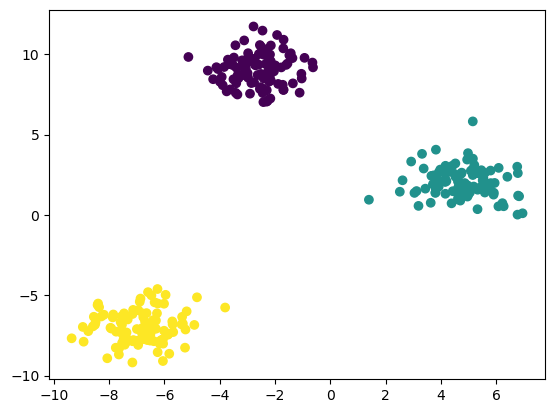

In [78]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [79]:
n_outliers = 20
outliers = np.random.uniform(low=-10, high=10, size=(n_outliers, 2))

In [80]:
X_combined = np.vstack([X, outliers])

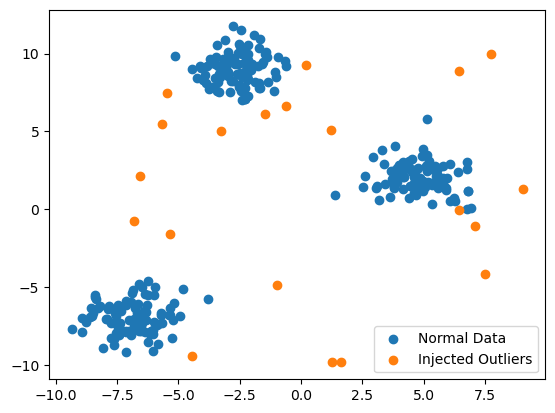

In [75]:
plt.scatter(X[:,0], X[:,1], label="Normal Data")
plt.scatter(outliers[:,0], outliers[:,1], label="Injected Outliers")
plt.legend()
plt.show()

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [81]:
X_scaled = scaler.fit_transform(X_combined)

In [83]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20)

In [88]:
labels = lof.fit_predict(X_scaled)

In [89]:
labels

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1, -1,  1,
        1, -1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
       -1,  1,  1,  1,  1

In [90]:
scores = lof.negative_outlier_factor_

In [94]:
scores

array([-0.99056922, -1.01206821, -1.12231446, -1.06902521, -1.42291066,
       -1.00707411, -0.96278893, -0.98226944, -0.95934551, -1.07739824,
       -1.33141999, -0.98374858, -1.16327454, -1.06998576, -0.98684696,
       -0.97762262, -1.121298  , -1.58851569, -0.98369069, -1.35096339,
       -1.2122415 , -0.95035796, -1.02624081, -0.97017945, -0.96518604,
       -1.11123556, -1.03908223, -1.58652914, -1.01041395, -1.06109507,
       -1.04227623, -1.02714783, -1.02922407, -1.04753111, -1.22731137,
       -1.10517093, -1.02468817, -0.99232698, -0.96251559, -1.35239315,
       -1.17626665, -0.96610175, -0.98082898, -1.08056538, -1.06089899,
       -1.15480003, -0.95931345, -0.97807542, -0.96629085, -1.36305039,
       -0.99438631, -1.11638924, -0.97709508, -1.23917301, -1.10692438,
       -2.7665007 , -0.97159697, -1.11343457, -1.02253391, -1.04814015,
       -1.04994228, -1.7448702 , -1.01058687, -2.02833714, -1.06532526,
       -0.99758164, -0.98652642, -1.05075611, -1.14576786, -1.02

In [91]:
normal_points = X_combined[labels == 1]
detected_outliers = X_combined[labels == -1]

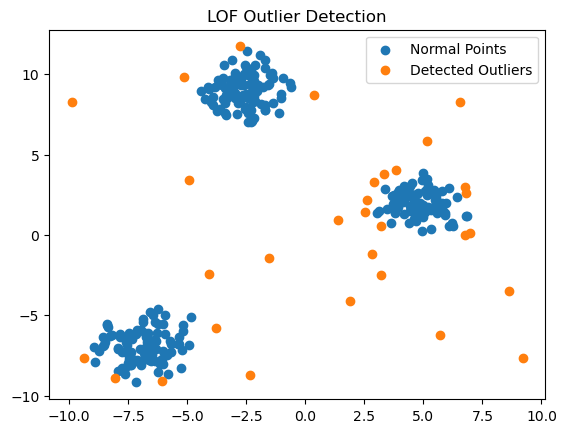

In [92]:
plt.figure()

plt.scatter(
    normal_points[:, 0],
    normal_points[:, 1],
    label="Normal Points"
)

plt.scatter(
    detected_outliers[:, 0],
    detected_outliers[:, 1],
    label="Detected Outliers"
)

plt.title("LOF Outlier Detection")
plt.legend()
plt.show()

In [93]:
print("Total points:", len(X_combined))
print("Outliers detected:", len(detected_outliers))

Total points: 320
Outliers detected: 31
